In [1]:
import math
from dataclasses import dataclass

# =========================
# Physical constants
# =========================
kB = 1.380649e-23      # Boltzmann constant, J/K
g  = 9.80665           # m/s^2
pi = math.pi

@dataclass
class Channel:
    width_m: float      # m
    height_m: float     # m
    length_m: float     # m

@dataclass
class Bead:
    diameter_m: float   # m
    density_kg_m3: float  # kg/m^3 (polystyrene ~1050)
    # fluid properties
    fluid_density_kg_m3: float = 997.0     # water at ~25C
    fluid_viscosity_Pa_s: float = 0.00089  # Pa·s water at ~25C
    temperature_K: float = 298.15          # K

@dataclass
class Flow:
    Q_m3_s: float        # m^3/s
    concentration_per_m3: float  # particles/m^3


# =========================
# Unit helpers
# =========================
def ul_per_hr_to_m3_per_s(Q_ul_hr: float) -> float:
    # 1 uL = 1e-9 m^3 ; 1 hr = 3600 s
    return Q_ul_hr * 1e-9 / 3600.0

def per_ml_to_per_m3(c_per_ml: float) -> float:
    # 1 mL = 1e-6 m^3
    return c_per_ml / 1e-6


# =========================
# Core calculations
# =========================
def average_velocity(flow: Flow, ch: Channel) -> float:
    A = ch.width_m * ch.height_m
    return flow.Q_m3_s / A

def residence_time(flow: Flow, ch: Channel) -> float:
    U = average_velocity(flow, ch)
    return ch.length_m / U

def reynolds_number(flow: Flow, ch: Channel, bead: Bead) -> float:
    # Use hydraulic diameter for a rectangular channel:
    # Dh = 2wh/(w+h)
    w, h = ch.width_m, ch.height_m
    Dh = 2*w*h/(w+h)
    U  = average_velocity(flow, ch)
    rho = bead.fluid_density_kg_m3
    mu  = bead.fluid_viscosity_Pa_s
    return rho * U * Dh / mu

def bead_diffusivity(bead: Bead) -> float:
    # Stokes-Einstein: D = kBT/(6*pi*mu*a)
    a = bead.diameter_m / 2.0
    mu = bead.fluid_viscosity_Pa_s
    T  = bead.temperature_K
    return kB * T / (6.0 * pi * mu * a)

def schmidt_number(bead: Bead, D: float) -> float:
    # Sc = nu/D = (mu/rho)/D
    mu  = bead.fluid_viscosity_Pa_s
    rho = bead.fluid_density_kg_m3
    nu  = mu / rho
    return nu / D

def bottom_collision_rate_diffusion_1D(flow: Flow, ch: Channel, bead: Bead, n_terms: int = 200) -> float:
    """
    Brownian collisions modeled as 1D diffusion across channel height h,
    with absorbing boundaries at y=0 (bottom) and y=h (top),
    starting from a UNIFORM distribution in y.
    
    Survival probability (uniform initial) for absorbing ends:
      S(t) = (8/pi^2) * sum_{m odd} (1/m^2) * exp(-m^2*pi^2*D*t/h^2)
    Absorption probability = 1 - S(t)
    By symmetry, bottom gets half of absorbed particles.

    Returns: particles/s colliding with bottom due to diffusion.
    """
    h = ch.height_m
    D = bead_diffusivity(bead)
    t = residence_time(flow, ch)

    # compute S(t)
    S = 0.0
    # odd m = 1,3,5,...
    for k in range(n_terms):
        m = 2*k + 1
        term = (1.0 / (m*m)) * math.exp(-(m*m)*(pi*pi)*D*t/(h*h))
        S += term
    S *= (8.0 / (pi*pi))

    p_absorb_total = max(0.0, min(1.0, 1.0 - S))
    p_absorb_bottom = 0.5 * p_absorb_total

    particle_throughput = flow.concentration_per_m3 * flow.Q_m3_s  # particles/s entering
    return particle_throughput * p_absorb_bottom

def cunningham_slip_correction(d_m: float, T_K: float = 298.15, p_Pa: float = 101325.0) -> float:
    """
    Cunningham correction is usually only important for sub-micron particles in gas.
    For 1 µm particles in WATER this is ~1 and can be ignored.
    Provided here for completeness; we return 1.0 by default.
    """
    return 1.0

def settling_velocity_stokes(bead: Bead) -> float:
    """
    Stokes settling in a viscous fluid:
      v = (2/9) * (Δρ * g * a^2) / μ * Cc
    """
    a  = bead.diameter_m / 2.0
    mu = bead.fluid_viscosity_Pa_s
    drho = bead.density_kg_m3 - bead.fluid_density_kg_m3
    Cc = cunningham_slip_correction(bead.diameter_m, bead.temperature_K)
    return (2.0/9.0) * (drho * g * a*a) / mu * Cc

def bottom_collision_rate_settling(flow: Flow, ch: Channel, bead: Bead) -> float:
    """
    Collisions due to gravitational settling:
    assume particles enter with uniform height distribution in [0,h].
    In time t_res, a particle falls distance d = v_settle * t_res.
    Fraction that reaches bottom before exiting: f = min(1, d/h).
    
    Deposition rate bottom = particle_throughput * f
    """
    h = ch.height_m
    t = residence_time(flow, ch)
    v = settling_velocity_stokes(bead)
    f = min(1.0, max(0.0, (v * t) / h))
    particle_throughput = flow.concentration_per_m3 * flow.Q_m3_s
    return particle_throughput * f

def summarize(flow: Flow, ch: Channel, bead: Bead):
    U = average_velocity(flow, ch)
    t = residence_time(flow, ch)
    D = bead_diffusivity(bead)
    Re = reynolds_number(flow, ch, bead)
    Sc = schmidt_number(bead, D)
    v_settle = settling_velocity_stokes(bead)

    rate_diff = bottom_collision_rate_diffusion_1D(flow, ch, bead, n_terms=300)
    rate_set  = bottom_collision_rate_settling(flow, ch, bead)
    rate_tot  = rate_diff + rate_set

    bottom_area = ch.width_m * ch.length_m
    # Convert to flux on bottom (particles/m^2/s) for intuition:
    flux_tot = rate_tot / bottom_area

    print("=== Geometry / Flow ===")
    print(f"Width w       = {ch.width_m:.3e} m")
    print(f"Height h      = {ch.height_m:.3e} m")
    print(f"Length L      = {ch.length_m:.3e} m")
    print(f"Flow rate Q   = {flow.Q_m3_s:.3e} m^3/s")
    print(f"Area A        = {ch.width_m*ch.height_m:.3e} m^2")
    print(f"Mean velocity = {U:.3e} m/s")
    print(f"Residence t   = {t:.3e} s")

    print("\n=== Bead / Transport ===")
    print(f"Bead diameter = {bead.diameter_m:.3e} m")
    print(f"Diffusivity D = {D:.3e} m^2/s")
    print(f"Settling vel  = {v_settle:.3e} m/s")
    print(f"Re            = {Re:.3e} (laminar if << 2000)")
    print(f"Sc            = {Sc:.3e}")

    print("\n=== Collision (bottom wall) rates ===")
    print(f"Conc          = {flow.concentration_per_m3:.3e} 1/m^3")
    print(f"Throughput    = {flow.concentration_per_m3*flow.Q_m3_s:.3e} beads/s entering")
    print(f"Diffusion     = {rate_diff:.3e} beads/s")
    print(f"Settling      = {rate_set:.3e} beads/s")
    print(f"TOTAL         = {rate_tot:.3e} beads/s")
    print(f"Bottom flux   = {flux_tot:.3e} beads/(m^2·s)")

# =========================
# Plug in YOUR numbers
# =========================
if __name__ == "__main__":
    ch = Channel(
        width_m  = 5e-3,     # 5 mm
        height_m = 50e-6,    # 50 um
        length_m = 20e-3     # 20 mm
    )

    bead = Bead(
        diameter_m = 1e-6,        # 1 um bead
        density_kg_m3 = 1050.0    # polystyrene ~1050 kg/m^3
    )

    flow = Flow(
        Q_m3_s = ul_per_hr_to_m3_per_s(1000.0),         # 1000 uL/hr
        concentration_per_m3 = per_ml_to_per_m3(1e8)    # 1e8 / mL
    )

    summarize(flow, ch, bead)

=== Geometry / Flow ===
Width w       = 5.000e-03 m
Height h      = 5.000e-05 m
Length L      = 2.000e-02 m
Flow rate Q   = 2.778e-10 m^3/s
Area A        = 2.500e-07 m^2
Mean velocity = 1.111e-03 m/s
Residence t   = 1.800e+01 s

=== Bead / Transport ===
Bead diameter = 1.000e-06 m
Diffusivity D = 4.907e-13 m^2/s
Settling vel  = 3.244e-08 m/s
Re            = 1.232e-01 (laminar if << 2000)
Sc            = 1.819e+06

=== Collision (bottom wall) rates ===
Conc          = 1.000e+14 1/m^3
Throughput    = 2.778e+04 beads/s entering
Diffusion     = 1.863e+03 beads/s
Settling      = 3.244e+02 beads/s
TOTAL         = 2.188e+03 beads/s
Bottom flux   = 2.188e+07 beads/(m^2·s)


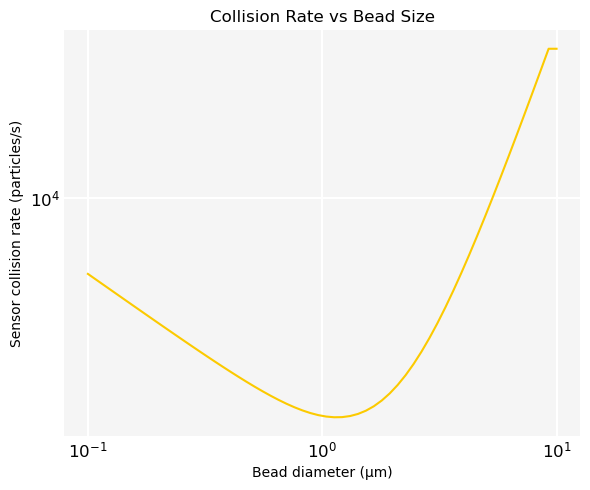

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import sys
sys.path.insert(0,'/home/taiy/stdplot/2a_tools/code')  # add lab code repo directory to sys.path so the program is aware where to import modules
import plot as labplot
capple = labplot.colors.colors_apple

# =========================
# Physical constants
# =========================
kB = 1.380649e-23
g  = 9.80665
pi = math.pi

# =========================
# Fixed system parameters (YOUR specs)
# =========================
# Channel geometry
w = 5e-3      # width  = 5 mm
h = 50e-6     # height = 50 um
L = 20e-3     # length = 20 mm

# Fluid properties (water ~25C)
rho_f = 997.0
mu = 0.00089
T = 298.15

# Bead material (polystyrene)
rho_p = 1050.0

# Flow rate
Q = 1000e-9 / 3600.0   # 1000 uL/hr -> m^3/s

# Bead concentration (fixed) = 1e8 / mL
conc_per_m3 = 1e8 / 1e-6  # 1/m^3

# =========================
# Derived flow quantities
# =========================
A = w * h
U = Q / A
t_res = L / U

# =========================
# Brownian diffusion: bottom-wall hit probability
# (1D diffusion across height with absorbing walls, uniform initial distribution)
# =========================
def diffusion_bottom_probability(D, h, t, n_terms=300):
    S = 0.0
    for k in range(n_terms):
        m = 2 * k + 1  # odd terms: 1,3,5,...
        S += (1.0 / (m * m)) * math.exp(-(m * m) * (pi * pi) * D * t / (h * h))
    S *= (8.0 / (pi * pi))          # survival probability
    p_total_absorb = 1.0 - S        # absorbed by either wall
    return 0.5 * p_total_absorb     # half to bottom by symmetry

# =========================
# Bead size sweep (0.1 µm to 10 µm)
# =========================
diameters_um = np.logspace(-1, 1, 60)  # µm
diameters_m  = diameters_um * 1e-6

throughput = conc_per_m3 * Q  # beads/s entering the channel
collision_rates = []

for d in diameters_m:
    a = d / 2.0
    # Stokes–Einstein diffusivity
    D = kB * T / (6.0 * pi * mu * a)

    # Diffusion contribution (probability to hit bottom during residence)
    p_diff_bottom = diffusion_bottom_probability(D, h, t_res, n_terms=300)

    # Gravitational settling velocity (Stokes)
    v_settle = (2.0 / 9.0) * ((rho_p - rho_f) * g * a * a) / mu

    # Fraction that can reach bottom within residence time (uniform initial height)
    f_settle = min(1.0, max(0.0, (v_settle * t_res) / h))

    # Total bottom collision rate (diffusion + settling)
    rate = throughput * (p_diff_bottom + f_settle)
    collision_rates.append(rate)

collision_rates = np.array(collision_rates)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(diameters_um, collision_rates, color=capple['apple_yellow'])
ax.set_facecolor('whitesmoke')  # light grey background
ax.grid(True, linewidth = 1.5, color='white') # White grid lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlabel("Bead diameter (µm)")
ax.set_ylabel("Sensor collision rate (particles/s)")
ax.set_title("Collision Rate vs Bead Size")
ax.tick_params(axis='both', direction='in', labelsize=12, which='both', length=0, width = 1)  # tick configuration
ax.tick_params(axis='both', direction='in', labelsize=12, which='minor', length=0, width = 0.5) # tick configuration
ax.grid(True)
fig.tight_layout()
plt.show()

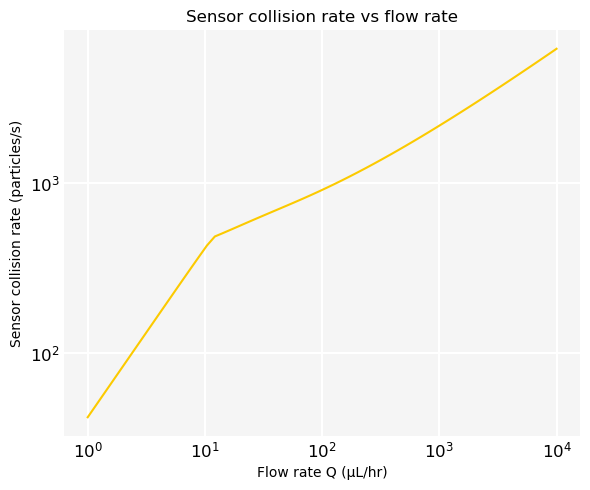

In [4]:
import math
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Physical constants
# =========================
kB = 1.380649e-23      # Boltzmann constant, J/K
g  = 9.80665           # m/s^2
pi = math.pi

@dataclass
class Channel:
    width_m: float      # m
    height_m: float     # m
    length_m: float     # m

@dataclass
class Bead:
    diameter_m: float          # m
    density_kg_m3: float       # kg/m^3 (polystyrene ~1050)
    # fluid properties
    fluid_density_kg_m3: float = 997.0     # water at ~25C
    fluid_viscosity_Pa_s: float = 0.00089  # Pa·s water at ~25C
    temperature_K: float = 298.15          # K

@dataclass
class Flow:
    Q_m3_s: float                 # m^3/s
    concentration_per_m3: float   # particles/m^3

# =========================
# Unit helpers
# =========================
def ul_per_hr_to_m3_per_s(Q_ul_hr: float) -> float:
    return Q_ul_hr * 1e-9 / 3600.0

def per_ml_to_per_m3(c_per_ml: float) -> float:
    return c_per_ml / 1e-6

# =========================
# Core calculations
# =========================
def average_velocity(flow: Flow, ch: Channel) -> float:
    A = ch.width_m * ch.height_m
    return flow.Q_m3_s / A

def residence_time(flow: Flow, ch: Channel) -> float:
    U = average_velocity(flow, ch)
    return ch.length_m / U

def reynolds_number(flow: Flow, ch: Channel, bead: Bead) -> float:
    w, h = ch.width_m, ch.height_m
    Dh = 2 * w * h / (w + h)
    U  = average_velocity(flow, ch)
    rho = bead.fluid_density_kg_m3
    mu  = bead.fluid_viscosity_Pa_s
    return rho * U * Dh / mu

def bead_diffusivity(bead: Bead) -> float:
    a = bead.diameter_m / 2.0
    mu = bead.fluid_viscosity_Pa_s
    T  = bead.temperature_K
    return kB * T / (6.0 * pi * mu * a)

def schmidt_number(bead: Bead, D: float) -> float:
    mu  = bead.fluid_viscosity_Pa_s
    rho = bead.fluid_density_kg_m3
    nu  = mu / rho
    return nu / D

def bottom_collision_rate_diffusion_1D(
    flow: Flow, ch: Channel, bead: Bead, n_terms: int = 200
) -> float:
    h = ch.height_m
    D = bead_diffusivity(bead)
    t = residence_time(flow, ch)

    S = 0.0
    for k in range(n_terms):
        m = 2 * k + 1
        S += (1.0 / (m * m)) * math.exp(-(m * m) * (pi * pi) * D * t / (h * h))

    S *= (8.0 / (pi * pi))
    p_absorb_total = max(0.0, min(1.0, 1.0 - S))
    p_absorb_bottom = 0.5 * p_absorb_total

    particle_throughput = flow.concentration_per_m3 * flow.Q_m3_s
    return particle_throughput * p_absorb_bottom

def cunningham_slip_correction(
    d_m: float, T_K: float = 298.15, p_Pa: float = 101325.0
) -> float:
    return 1.0

def settling_velocity_stokes(bead: Bead) -> float:
    a   = bead.diameter_m / 2.0
    mu  = bead.fluid_viscosity_Pa_s
    drho = bead.density_kg_m3 - bead.fluid_density_kg_m3
    Cc  = cunningham_slip_correction(bead.diameter_m, bead.temperature_K)
    return (2.0 / 9.0) * (drho * g * a * a) / mu * Cc

def bottom_collision_rate_settling(flow: Flow, ch: Channel, bead: Bead) -> float:
    h = ch.height_m
    t = residence_time(flow, ch)
    v = settling_velocity_stokes(bead)
    f = min(1.0, max(0.0, (v * t) / h))
    particle_throughput = flow.concentration_per_m3 * flow.Q_m3_s
    return particle_throughput * f

def total_bottom_collision_rate(flow: Flow, ch: Channel, bead: Bead) -> float:
    rate_diff = bottom_collision_rate_diffusion_1D(flow, ch, bead, n_terms=300)
    rate_set  = bottom_collision_rate_settling(flow, ch, bead)
    return rate_diff + rate_set

# =========================
# Sweep over flow rate and plot
# =========================
if __name__ == "__main__":
    # Fixed geometry and bead
    ch = Channel(
        width_m  = 5e-3,     # 5 mm
        height_m = 50e-6,    # 50 µm
        length_m = 20e-3     # 20 mm
    )
    bead = Bead(
        diameter_m = 1e-6,        # 1 µm
        density_kg_m3 = 1050.0
    )
    conc = per_ml_to_per_m3(1e8)  # 1e8 / mL

    # Define flow rate range in uL/hr (log-spaced)
    Q_ul_hr_array = np.logspace(0, 4, 60)  # 1 to 10^4 uL/hr
    Q_m3_s_array  = ul_per_hr_to_m3_per_s(Q_ul_hr_array)

    collision_rates = []
    for Q_m3_s in Q_m3_s_array:
        flow = Flow(Q_m3_s=Q_m3_s, concentration_per_m3=conc)
        rate_tot = total_bottom_collision_rate(flow, ch, bead)
        collision_rates.append(rate_tot)
    collision_rates = np.array(collision_rates)

    # Plot: collision rate vs flow rate
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.loglog(Q_ul_hr_array, collision_rates, color=capple['apple_yellow'])
    ax.set_facecolor('whitesmoke')  # light grey background
    ax.grid(True, linewidth = 1.5, color='white') # White grid lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xlabel("Flow rate Q (µL/hr)")
    ax.set_ylabel("Sensor collision rate (particles/s)")
    ax.set_title("Sensor collision rate vs flow rate")
    ax.tick_params(axis='both', direction='in', labelsize=12, which='both', length=0, width = 1)  # tick configuration
    ax.tick_params(axis='both', direction='in', labelsize=12, which='minor', length=0, width = 0.5) # tick configuration
    fig.tight_layout()
    plt.show()